In [ ]:
import os
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax.flatten_util import ravel_pytree

# -----------------------------
# Basic MLP transport T_theta : R^d -> R^d
# -----------------------------
def glorot(k, fin, fout):
    lim = jnp.sqrt(6.0 / (fin + fout))
    return jax.random.uniform(k, (fin, fout), minval=-lim, maxval=lim)

def init_mlp_params(sizes, key):
    keys = jax.random.split(key, len(sizes)-1)
    params = []
    for k, (fin, fout) in zip(keys, zip(sizes[:-1], sizes[1:])):
        W = glorot(k, fin, fout)
        b = jnp.zeros((fout,))
        params.append((W, b))
    return params

def mlp_forward(params, x, activation=jax.nn.gelu):
    h = x
    for (W, b) in params[:-1]:
        h = activation(h @ W + b)
    W, b = params[-1]
    return h @ W + b  # output in R^d

# Convenience wrappers
def T_apply(params, z):
    return mlp_forward(params, z)

# -----------------------------
# Reference q0 and target score ∇ log π
# -----------------------------
def sample_q0(key, n, d):
    return jax.random.normal(key, (n, d))  # N(0, I)

def score_target_standard_normal(x):
    # π = N(0, I): ∇ log π(x) = -x
    return -x

def make_gaussian_score(mu, sigma):
    mu = jnp.asarray(mu)
    inv_var = 1.0 / (jnp.asarray(sigma) ** 2)
    def score(x):
        return -(x - mu) * inv_var
    return score

# -----------------------------
# Stein gradient pieces
# -----------------------------
def make_ravel_T(T_fun, params_example, d):
    theta0, unravel = ravel_pytree(params_example)
    def T_with_theta(theta, z):
        params = unravel(theta)
        return T_fun(params, z)
    return T_with_theta, unravel, theta0

def per_sample_grad_terms(theta, z, T_theta_fn, score_fn):
    """
    Returns per-sample contribution g(z; theta) in R^P for the Stein-KL gradient:
    g = - [ div_x Phi(theta; z) + Phi(theta; z)^T score(x) ] where x = T_theta(z).
    """
    x = T_theta_fn(theta, z)                # (d,)
    s = score_fn(x)                         # (d,)

    # Phi^T s via VJP wrt theta
    _, vjp_theta = jax.vjp(lambda th: T_theta_fn(th, z), theta)
    phiT_s = vjp_theta(s)[0]                # (P,)

    # Divergence term
    J_T = jax.jacrev(lambda zz: T_theta_fn(theta, zz))(z)  # (d,d)



    def Phi_flat(z_):
        J_theta = jax.jacrev(lambda th: T_theta_fn(th, z_))(theta)  # (P, d)
        return J_theta.T  # (d, P)

    # z-Jacobian of Phi: shape from jacrev is (d, d, P); transpose to (d, P, d)
    # z-Jacobian of Phi: (d, d, P) -> (d, P, d)
    J_Phi = jax.jacrev(Phi_flat)(z)
    J_Phi = jnp.transpose(J_Phi, (0, 2, 1))  # (d, P, d)

    # Solve J_T @ Y = J_Phi for all parameter blocks at once.
    # Reshape RHS to (d, P*d), solve once, then reshape back and take per-block traces.
    d = J_T.shape[0]
    P = J_Phi.shape[1]
    J_Phi_flat = J_Phi.reshape(d, P * d)            # (d, P*d)
    Y_flat = jnp.linalg.solve(J_T, J_Phi_flat)      # (d, P*d)
    Y_blocks = Y_flat.reshape(d, P, d)              # (d, P, d)
    div = jnp.einsum('dpd->p', Y_blocks)            # (P,)


    return -(div + phiT_s)                          # (P,)

per_batch_grad_terms = jax.vmap(per_sample_grad_terms, in_axes=(None, 0, None, None))

def stein_kl_grad(theta, z_batch, T_theta_fn, score_fn):
    g_batch = per_batch_grad_terms(theta, z_batch, T_theta_fn, score_fn)  # (N, P)
    return jnp.mean(g_batch, axis=0)  # (P,)

# -----------------------------
# Training loop (square flow case)
# -----------------------------
def train_flow_stein_kl(d=2, hidden=(64,64), steps=600, batch_size=96, lr=1e-3,
                        key=jax.random.PRNGKey(0), score_fn=score_target_standard_normal):
    key_init, key_data = jax.random.split(key)
    sizes = [d, *hidden, d]
    params = init_mlp_params(sizes, key_init)

    T_theta_fn, unravel, theta = make_ravel_T(lambda p,z: T_apply(p, z), params, d)

    def zeros_like_theta(th): return jnp.zeros_like(th)
    opt_state = (jnp.array(0, dtype=jnp.int32), zeros_like_theta(theta), zeros_like_theta(theta))

    @jax.jit
    def adam_step(theta, grad, opt_state, lr=1e-3, b1=0.9, b2=0.999, eps=1e-8):
        t, m, v = opt_state
        t = t + 1
        m = b1*m + (1-b1)*grad
        v = b2*v + (1-b2)*(grad*grad)
        mhat = m / (1 - b1**t)
        vhat = v / (1 - b2**t)
        theta2 = theta - lr * mhat / (jnp.sqrt(vhat) + eps)
        return theta2, (t, m, v)

    @jax.jit
    def step(theta, key, opt_state):
        z = sample_q0(key, batch_size, d)
        g = stein_kl_grad(theta, z, T_theta_fn, score_fn)  # (P,)
        theta2, opt2 = adam_step(theta, g, opt_state, lr=lr)
        return theta2, opt2, g

    hist = []
    for t in range(steps):
        key_data, kb = jax.random.split(key_data)
        theta, opt_state, g = step(theta, kb, opt_state)
        if (t % 20) == 0:
            hist.append(jnp.linalg.norm(g))

    params_trained = unravel(theta)
    return params_trained, jnp.array(hist)



In [10]:
# Train on the standard normal target
params_trained, hist = train_flow_stein_kl(
    d=2, hidden=(64, 64), steps=600, batch_size=96, lr=1e-3, key=jax.random.PRNGKey(0)
)

# Plot 1: Gradient norm history (logged every 20 steps)
iters = jnp.arange(len(hist)) * 20
plt.figure()
plt.plot(iters, hist)
plt.title("Training: ||gradient|| over iterations")
plt.xlabel("Iteration")
plt.ylabel("Gradient norm")
plt.tight_layout()
plt.savefig("grad_norm_history.png", dpi=150)

# Plot 2: Base samples
key = jax.random.PRNGKey(123)
z = sample_q0(key, 2000, 2)
plt.figure()
plt.scatter(z[:, 0], z[:, 1], s=5, alpha=0.5)
plt.title("Base samples z ~ N(0, I)")
plt.xlabel("z1")
plt.ylabel("z2")
plt.tight_layout()
plt.savefig("base_samples.png", dpi=150)

# Plot 3: Transformed samples
x = T_apply(params_trained, z)
plt.figure()
plt.scatter(x[:, 0], x[:, 1], s=5, alpha=0.5)
plt.title("Transformed samples x = T_θ(z)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.tight_layout()
# plt.savefig("transformed_samples.png", dpi=150)

# print("Saved: grad_norm_history.png, base_samples.png, transformed_samples.png")


TypeError: cannot reshape array of shape (4482, 2, 2) (size 17928) into shape (2, 4) (size 8)

In [93]:
# pip install jax jaxlib (or use a JAX runtime like Google Colab / TPU)
import jax
import jax.numpy as jnp
from jax import random, vmap
from functools import partial

# ----------------------------
# Target: 2D Gaussian mixture
# ----------------------------
def logsumexp(a, axis=None):
    m = jnp.max(a, axis=axis, keepdims=True)
    return (m + jnp.log(jnp.sum(jnp.exp(a - m), axis=axis, keepdims=True))).squeeze()

def log_gauss(x, mean, cov_inv, logdet_cov):
    # x: (..., d), mean: (d,), cov_inv: (d,d)
    d = x.shape[-1]
    dx = x - mean
    return -0.5 * (jnp.einsum('...i,ij,...j', dx, cov_inv, dx) + logdet_cov + d*jnp.log(2*jnp.pi))

def make_mixture_target(means, covs):
    # means: (K,d), covs: (K,d,d)
    K, d = means.shape
    cov_invs = jnp.linalg.inv(covs)
    logdets = jnp.log(jnp.linalg.det(covs))
    weights = jnp.ones((K,)) / K

    def logpi(x):
        # x: (..., d)
        # compute mixture log-density
        # Need to compute log_gauss for each component and each point
        comps = vmap(lambda m, Ci, ld: log_gauss(x, m, Ci, ld), (0,0,0))(means, cov_invs, logdets)  # (K, ...)
        # Broadcast weights properly with component scores
        log_weights = jnp.log(weights)
        if comps.ndim > 1:
            log_weights = log_weights[:, None]
        return logsumexp(log_weights + comps, axis=0)
    return logpi

# ----------------------------
# Isotropic Gaussian proposal
# ----------------------------
def gaussian_propose(key, x, sigma):
    # symmetric proposal q(y|x)=N(x, sigma^2 I)
    eps = random.normal(key, shape=x.shape) * sigma
    return x + eps

# ----------------------------
# RBF kernel and utilities
# ----------------------------
def pairwise_sqdist(X, Y):
    # X: (n,d), Y: (m,d) -> (n,m)
    XX = jnp.sum(X**2, axis=1, keepdims=True)
    YY = jnp.sum(Y**2, axis=1, keepdims=True).T
    return XX + YY - 2 * (X @ Y.T)

def median_heuristic_bandwidth(X):
    # X: (n,d)
    n = X.shape[0]
    d2 = pairwise_sqdist(X, X)
    # take upper triangle excluding diagonal
    # Instead of boolean indexing, use where to mask values
    mask = jnp.triu(jnp.ones((n, n)), k=1)
    # Set lower triangle and diagonal to large value for median calculation
    d2_masked = jnp.where(mask > 0, d2, jnp.inf)
    # Flatten and compute median, ignoring inf values
    vals_flat = d2_masked.flatten()
    vals_sorted = jnp.sort(vals_flat)
    # Count non-inf values
    n_valid = jnp.sum(mask).astype(jnp.int32)
    # Get median of valid values
    med_idx = n_valid // 2
    med = vals_sorted[med_idx]
    # bandwidth for RBF: k(x,y)=exp(-||x-y||^2/(2*h^2))
    h = jnp.sqrt(0.5 * med + 1e-6)
    return jnp.maximum(h, 1e-3)

def rbf_kernel(X, Y, h):
    # X: (n,d), Y: (m,d)
    d2 = pairwise_sqdist(X, Y)
    return jnp.exp(-d2 / (2.0 * h**2))

# -------------------------------------------
# Build kernel potential psi* from particles
# -------------------------------------------
def build_kernel_potential(particles, prop_points, alphas, lam=1e-6):
    """
    psi*(·) ≈ argmax_{||psi||_H<=1} E_rho[L psi]  -> representer h_hat in RKHS
    h_hat(z) = E_i,m [ alpha(x_i, y_{i,m}) (k(z, y_{i,m}) - k(z, x_i)) ]

    We project h_hat onto span{ k(·, u_l) } with dictionary U = particles ∪ prop_points
    and set psi*(·) = sum_l beta_l k(·, u_l), where (K + λ I) beta = b, b_l = h_hat(u_l).
    """
    X = particles             # (N,d)
    Y = prop_points.reshape(-1, X.shape[1])  # (N*M, d)
    A = alphas.reshape(-1, 1) # (N*M,1)

    U = jnp.concatenate([X, Y], axis=0)     # dictionary (D,d), D=N+N*M
    h = median_heuristic_bandwidth(U)
    K_UU = rbf_kernel(U, U, h)              # (D,D)

    # Build b = h_hat(U) = mean_{i,m}[ alpha * (k(U, y_{i,m}) - k(U, x_i)) ]
    K_UY = rbf_kernel(U, Y, h)              # (D, N*M)
    K_UX = rbf_kernel(U, X, h)              # (D, N)
    
    # Need per-proposal subtraction aligned with each (i,m)
    # Each particle x_i corresponds to M proposals
    N = X.shape[0]
    M = Y.shape[0] // N
    
    # Repeat each column of K_UX M times to match the proposal structure
    # K_UX has shape (D, N), we want (D, N*M)
    K_UX_rep = jnp.repeat(K_UX, M, axis=1)  # (D, N*M)

    # Weighted average with alpha
    numer = jnp.sum(A.T * (K_UY - K_UX_rep), axis=1)  # (D,)
    b = numer / (N * M)

    # Solve (K + λ I) beta = b
    D = K_UU.shape[0]
    beta = jnp.linalg.solve(K_UU + lam * jnp.eye(D), b)  # (D,)

    # Return a callable psi(x) = k(x,U) @ beta
    def psi_fn(x):
        # x: (..., d)
        x_flat = x.reshape(-1, x.shape[-1])
        K_xU = rbf_kernel(x_flat, U, h)   # (B, D)
        val = K_xU @ beta                 # (B,)
        return val.reshape(x.shape[:-1])
    return psi_fn

# ----------------------------
# Vanilla Metropolis–Hastings
# ----------------------------
@partial(jax.jit, static_argnames=("logpi","T","sigma"))
def run_vanilla_mh(key, x0, logpi, T=1000, sigma=0.5):
    """
    Returns:
      xs: (T,N,d)
      acc_rate: scalar
      accs: (T,) mean acceptance per iteration
    """
    N, d = x0.shape

    def mh_step(carry, t):
        key, x = carry
        key, key_prop, key_acc = random.split(key, 3)
        keys = random.split(key_prop, N)
        y = vmap(gaussian_propose, in_axes=(0,0,None))(keys, x, sigma)  # (N,d)
        loga = jnp.minimum(0.0, logpi(y) - logpi(x))                    # symmetric proposal
        u = random.uniform(key_acc, shape=(N,))
        accept = (jnp.log(u) < loga)
        x_new = jnp.where(accept[:,None], y, x)
        return (key, x_new), (x_new, jnp.mean(accept))

    carry = (key, x0)
    (final_key, _), (xs, accs) = jax.lax.scan(mh_step, carry, jnp.arange(T))
    return xs, jnp.mean(accs), accs



# ------------------------------------------
# Kernelised MH (K-MH): tilt + MH correction
# ------------------------------------------
def sample_proposals(key, X, sigma, M):
    # For each particle x_i, generate M proposals with independent keys
    N, d = X.shape
    keys = random.split(key, N*M)
    X_rep = jnp.repeat(X, repeats=M, axis=0)
    Y = vmap(gaussian_propose, in_axes=(0,0,None))(keys, X_rep, sigma)
    return Y.reshape(N, M, d)

def mh_accept(logpi, x, y):
    return jnp.minimum(1.0, jnp.exp(logpi(y) - logpi(x)))  # symmetric q

# @partial(jax.jit, static_argnames=("logpi","T","sigma","M"))
# def run_kernel_mh(key, x0, logpi, T=500, sigma=0.5, M=2, eps=0.05, lam=1e-6,
#                   norm_delta=True):
#     """
#     Returns:
#       Xs: (T,N,d)
#       acc_mean: scalar mean MH accept across iterations
#       tilt_pass_mean: scalar mean tilt-pass across iterations
#       acc_series: (T,) mean MH acceptance per iteration
#       tilt_series: (T,) mean tilt-pass per iteration
#       diags: dict of arrays (T,N,...) with last-iter fields for plotting:
#              'X','Y1','pass_tilt','accept_mh','psi_x','psi_y','delta','delta_tilde','std_delta','s'
#     """
#     N, d = x0.shape

#     def one_iter(carry, t):
#         key, X = carry
#         key, key_prop, key_tilt, key_mh = random.split(key, 4)

#         # (A) Build psi from current X using M proposals per chain
#         Y = sample_proposals(key_prop, X, sigma, M)  # (N,M,d)
#         alphas = vmap(lambda xi, Yi: vmap(lambda y: mh_accept(logpi, xi, y))(Yi))(X, Y)  # (N,M)
#         psi = build_kernel_potential(X, Y, alphas, lam=lam)

#         # (B) K-MH step: new single proposal per chain
#         keys1 = random.split(key_tilt, N)
#         keys2 = random.split(key_mh, N)
#         Y1 = vmap(gaussian_propose, in_axes=(0,0,None))(keys1, X, sigma)  # (N,d)

#         psi_x = psi(X).reshape(-1)   # (N,)
#         psi_y = psi(Y1).reshape(-1)  # (N,)
#         delta = psi_y - psi_x        # (N,)

#         # --- Std normalisation of delta (per iteration) ---
#         if norm_delta:
#             std_delta = jnp.maximum(jnp.std(delta), 1e-8)
#             delta_tilde = delta / std_delta
#         else:
#             std_delta = jnp.array(jnp.nan, dtype=delta.dtype)
#             delta_tilde = delta

#         # --- Tilt prescreen ---
#         s = jnp.minimum(1.0, jnp.exp(eps * delta_tilde))  # (N,)
#         u1 = vmap(random.uniform)(keys1)                  # (N,)
#         pass_tilt = (u1 < s)

#         # (C) MH accept/reject
#         loga = jnp.minimum(0.0, logpi(Y1) - logpi(X))     # (N,)
#         u2 = vmap(random.uniform)(keys2)
#         accept_mh = (jnp.log(u2) < loga) & pass_tilt      # (N,)

#         X_new = jnp.where(accept_mh[:, None], Y1, X)

#         acc_mean = jnp.mean(accept_mh)
#         tilt_mean = jnp.mean(pass_tilt)

#         diag = {
#             "X": X, "Y1": Y1, "pass_tilt": pass_tilt, "accept_mh": accept_mh,
#             "psi_x": psi_x, "psi_y": psi_y, "delta": delta,
#             "delta_tilde": delta_tilde, "std_delta": std_delta, "s": s,
#         }
#         return (key, X_new), (X_new, acc_mean, tilt_mean, diag)

#     carry = (key, x0)
#     (final_key, _), (Xs, accs, tilt_pass, diags) = jax.lax.scan(one_iter, carry, jnp.arange(T))
#     return Xs, jnp.mean(accs), jnp.mean(tilt_pass), accs, tilt_pass, diags

from functools import partial
import jax
import jax.numpy as jnp
from jax import random, vmap

# Assumed utilities you already have:
# - sample_proposals(key, X, sigma, M) -> (N, M, d)
# - gaussian_propose(key, x, sigma) -> (d,)
# - build_kernel_potential(X, Y, alphas, lam) -> psi_fn: R^d -> R
# - logpi: callable R^{N,d} -> R^N
# - mh_accept(logpi, x, y) used only to build alphas for psi (unchanged)

def _std_normalise_deltas(d, eps=1e-8):
    # d: (N, M) per-chain deltas
    std = jnp.maximum(jnp.std(d, axis=1, keepdims=True), eps)  # (N,1)
    return d / std, std.squeeze(-1)

def _gumbel_max_sample(key, logits):
    # logits: (N, M)
    g = random.gumbel(key, logits.shape)
    idx = jnp.argmax(logits + g, axis=1)  # (N,)
    return idx

@partial(jax.jit, static_argnames=("logpi","T","sigma","M"))
def run_kernel_mh(key, x0, logpi, T=500, sigma=0.5, M=4, eps=0.1, lam=1e-6,
                      norm_delta=True):
    """
    Multiple-Try MH with categorical self-normalised kernel tilt (no 'tilt pass').

    Returns:
      Xs: (T,N,d)
      acc_mean: scalar mean MH accept across iterations
      acc_series: (T,) mean MH acceptance per iteration
      diags: dict with last-iter fields for plotting/inspection:
             'X','Y_fwd','idx_fwd','sumw_fwd','sumw_rev','psi_x','psi_Y','delta_fwd','delta_rev','std_fwd','std_rev'
    """
    N, d = x0.shape

    def one_iter(carry, t):
        key, X = carry
        key, k_prop_fwd, k_sel, k_rev, k_mh = random.split(key, 5)

        # (A) Build psi from current X using M proposals per chain (same as before)
        Y_for_psi = sample_proposals(k_prop_fwd, X, sigma, M)                  # (N,M,d)
        alphas = vmap(lambda xi, Yi: vmap(lambda y: mh_accept(logpi, xi, y))(Yi))(X, Y_for_psi)  # (N,M)
        psi = build_kernel_potential(X, Y_for_psi, alphas, lam=lam)

        # (B) Forward set: draw M proposals per chain from base q
        Y_fwd = sample_proposals(k_prop_fwd, X, sigma, M)                       # (N,M,d)

        psi_x = psi(X).reshape(-1, )                                            # (N,)
        psi_Y = vmap(lambda Yi: psi(Yi).reshape(-1))(Y_fwd)                     # (N,M)
        delta_fwd = psi_Y - psi_x[:, None]                                      # (N,M)

        # Per-chain std normalisation (optional) for stable logits
        if norm_delta:
            delta_fwd_tilde, std_fwd = _std_normalise_deltas(delta_fwd)
        else:
            delta_fwd_tilde, std_fwd = delta_fwd, jnp.full((N,), jnp.nan)

        # (C) Categorical selection of one proposal via softmax over eps * delta
        logits_fwd = eps * delta_fwd_tilde                                      # (N,M)
        idx_fwd = _gumbel_max_sample(k_sel, logits_fwd)                         # (N,)
        # Gather chosen proposals y and their deltas
        y_sel = jnp.take_along_axis(Y_fwd, idx_fwd[:, None, None], axis=1).squeeze(1)  # (N,d)
        # Forward weights and sum
        w_fwd = jnp.exp(logits_fwd)                                             # (N,M)
        sumw_fwd = jnp.sum(w_fwd, axis=1)                                       # (N,)

        # (D) Reverse set: from y_sel draw (M-1) proposals and include original x
        # Build (N, M, d) reverse set: concat x as first slot, then M-1 draws
        Y_rev_draws = sample_proposals(k_rev, y_sel, sigma, M-1)                # (N,M-1,d)
        X_expanded = X[:, None, :]                                              # (N,1,d)
        Y_rev = jnp.concatenate([X_expanded, Y_rev_draws], axis=1)              # (N,M,d)

        psi_y = psi(y_sel).reshape(-1,)                                         # (N,)
        psi_Yrev = vmap(lambda Zi: psi(Zi).reshape(-1))(Y_rev)                  # (N,M)
        delta_rev = psi_Yrev - psi_y[:, None]                                   # (N,M)

        if norm_delta:
            delta_rev_tilde, std_rev = _std_normalise_deltas(delta_rev)
        else:
            delta_rev_tilde, std_rev = delta_rev, jnp.full((N,), jnp.nan)

        logits_rev = eps * delta_rev_tilde                                      # (N,M)
        w_rev = jnp.exp(logits_rev)                                             # (N,M)
        sumw_rev = jnp.sum(w_rev, axis=1)                                       # (N,)

        # (E) Multiple-Try MH acceptance (Liu et al. 2000 style)
        # α = min(1, [π(y) * sum w_rev] / [π(x) * sum w_fwd])
        loga = (logpi(y_sel) + jnp.log(sumw_rev)) - (logpi(X) + jnp.log(sumw_fwd))  # (N,)
        u = random.uniform(k_mh, (N,))
        accept = jnp.log(u) < jnp.minimum(0.0, loga)

        X_new = jnp.where(accept[:, None], y_sel, X)

        acc_mean = jnp.mean(accept)

        diag = {
            "X": X, "Y_fwd": Y_fwd, "idx_fwd": idx_fwd,
            "sumw_fwd": sumw_fwd, "sumw_rev": sumw_rev,
            "psi_x": psi_x, "psi_Y": psi_Y, "delta_fwd": delta_fwd,
            "delta_rev": delta_rev, "std_fwd": std_fwd, "std_rev": std_rev,
        }
        return (key, X_new), (X_new, acc_mean, diag)

    carry = (key, x0)
    (final_key, _), (Xs, accs, diags) = jax.lax.scan(one_iter, carry, jnp.arange(T))
    return Xs, jnp.mean(accs), accs, diags


# ----------------------------
# Quick comparison experiment
# ----------------------------
if __name__ == "__main__":
    key = random.PRNGKey(0)
    d = 2
    means = jnp.array([[2.0, 0.0], [-2.0, 0.0]])
    covs = jnp.stack([jnp.eye(d) / 2, jnp.eye(d) / 2], axis=0)
    logpi = make_mixture_target(means, covs)

    N = 64                # parallel chains (reduced for testing)
    T = 200               # steps (reduced for testing)
    sigma = 0.5           # proposal std
    key, k1, k2 = random.split(key, 3)
    x0 = random.normal(k1, shape=(N, d)) * 3.0

    # Vanilla MH
    print("Running Vanilla MH...")
    xs_mh, acc_mh, accs_mh = run_vanilla_mh(k2, x0, logpi, T=T, sigma=sigma)

    # Kernelised MH
    key, k3 = random.split(key)
    print("Running Kernelised MH...")
    # xs_kmh, acc_kmh, pass_kmh, accs_kmh, tilt_pass, diags = run_kernel_mh(k3, x0, logpi, T=T//2, sigma=sigma, M=2, eps=0.05, lam=1e-5)
    xs_kmh, acc_kmh, accs_kmh, diags = run_kernel_mh(k3, x0, logpi, T=T, sigma=sigma, M=2, eps=0.05, lam=1e-5)

    # Simple diagnostics: empirical mean and acceptance
    mean_mh = jnp.mean(xs_mh[-200:].reshape(-1, d), axis=0)
    mean_kmh = jnp.mean(xs_kmh[-200:].reshape(-1, d), axis=0)

    print("Vanilla MH  acceptance:", float(acc_mh))
    print("Kernelised MH acceptance (final):", float(acc_kmh))
    # print("Kernelised MH tilt-pass rate:", float(pass_kmh))
    print("Empirical mean (MH):   ", mean_mh)
    print("Empirical mean (K-MH): ", mean_kmh)

Running Vanilla MH...
Running Kernelised MH...
Vanilla MH  acceptance: 0.6735937595367432
Kernelised MH acceptance (final): 0.6371093392372131
Empirical mean (MH):    [-0.31236804 -0.011226  ]
Empirical mean (K-MH):  [-0.44542274  0.04957695]


In [86]:
diags.keys()

dict_keys(['X', 'Y_fwd', 'delta_fwd', 'delta_rev', 'idx_fwd', 'psi_Y', 'psi_x', 'std_fwd', 'std_rev', 'sumw_fwd', 'sumw_rev'])

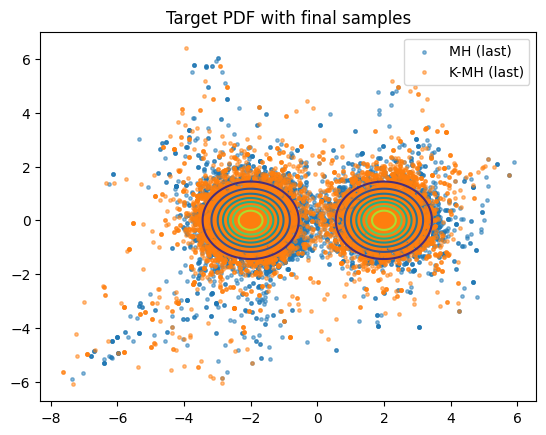

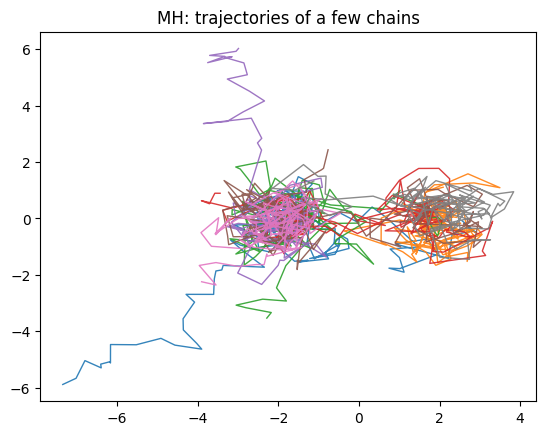

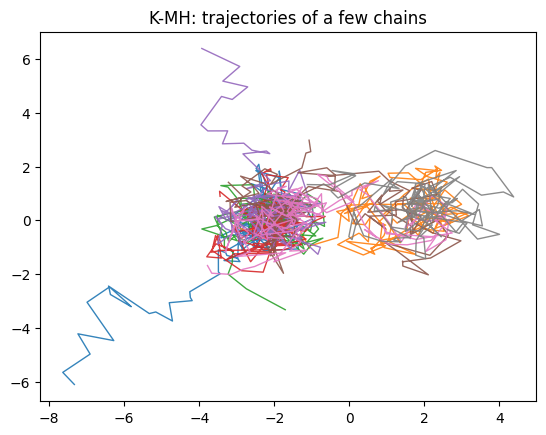

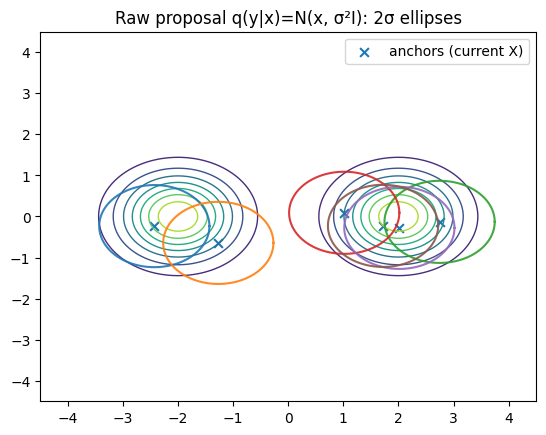

In [94]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- helpers ----------
def grid_eval_logpi(logpi, lim=4.5, n=220):
    xs = jnp.linspace(-lim, lim, n)
    ys = jnp.linspace(-lim, lim, n)
    Xg, Yg = jnp.meshgrid(xs, ys)
    pts = jnp.stack([Xg.reshape(-1), Yg.reshape(-1)], axis=1)
    lp = logpi(pts).reshape(n, n)
    return np.array(xs), np.array(ys), np.array(lp)

def final_tail(samples, last=200):
    T = samples.shape[0]
    use = min(last, T)
    tail = np.array(samples[-use:].reshape(-1, samples.shape[-1]))
    return tail

def draw_cov_ellipse(ax, mean, cov_scalar, n_std=2.0, num=200, **kw):
    # cov = cov_scalar^2 * I in 2D -> circle radius = n_std * cov_scalar
    r = n_std * cov_scalar
    theta = np.linspace(0, 2*np.pi, num)
    circ = np.stack([r*np.cos(theta), r*np.sin(theta)], axis=1)
    pts = circ + np.asarray(mean)
    ax.plot(pts[:,0], pts[:,1], **kw)

# ---------- compute grid for target ----------
xs_grid, ys_grid, logp_grid = grid_eval_logpi(logpi)

# ---------- figure 1: target contours + final samples ----------
fig1 = plt.figure()
ax1 = fig1.add_subplot(111)
ax1.contour(xs_grid, ys_grid, np.exp(logp_grid))
ax1.scatter(*final_tail(xs_mh).T, s=6, alpha=0.5, label="MH (last)")
ax1.scatter(*final_tail(xs_kmh).T, s=6, alpha=0.5, label="K-MH (last)")
ax1.set_title("Target PDF with final samples")
ax1.legend(loc="best")

# ---------- figure 2/3: a few chain paths ----------
k_show = min(8, xs_mh.shape[1])

fig2 = plt.figure()
ax2 = fig2.add_subplot(111)
mh_paths = np.array(xs_mh[:, :k_show, :])
for i in range(k_show):
    ax2.plot(mh_paths[:,i,0], mh_paths[:,i,1], linewidth=1, alpha=0.9)
ax2.set_title("MH: trajectories of a few chains")

fig3 = plt.figure()
ax3 = fig3.add_subplot(111)
kmh_paths = np.array(xs_kmh[:, :k_show, :])
for i in range(k_show):
    ax3.plot(kmh_paths[:,i,0], kmh_paths[:,i,1], linewidth=1, alpha=0.9)
ax3.set_title("K-MH: trajectories of a few chains")

# ---------- extract last-iter diagnostics from K-MH ----------
# diags is a dict of arrays (T,N,...) – take the final slice for plotting proposals
X_last         = np.array(diags["X"][-1])          # (N,2)
Y1_last        = np.array(diags["Y_fwd"][-1])         # (N,2)
delta_last     = np.array(diags["delta_rev"][-1])      # (N,)
# s_last         = np.array(diags["s"][-1])          # (N,)

# ---------- figure 4: visualise raw Gaussian proposals around a few anchors ----------
fig4 = plt.figure()
ax4 = fig4.add_subplot(111)
ax4.contour(xs_grid, ys_grid, np.exp(logp_grid), linewidths=1)
# pick a few anchor states to show proposal ellipses
idx = np.linspace(0, X_last.shape[0]-1, 6, dtype=int)
for i in idx:
    draw_cov_ellipse(ax4, X_last[i], cov_scalar=sigma, n_std=2.0, linewidth=1.5, alpha=0.9)
# also scatter the anchors
ax4.scatter(X_last[idx,0], X_last[idx,1], marker="x", s=40, label="anchors (current X)")
ax4.set_title("Raw proposal q(y|x)=N(x, σ²I): 2σ ellipses")
ax4.legend(loc="best")

plt.show()


/var/folders/y9/f2jq2rkn6h16kl4g9j02c2800000gn/T/ipykernel_74837/3821433876.py:212: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  cs_base.collections[0].set_label("Base q(y|x)")
/var/folders/y9/f2jq2rkn6h16kl4g9j02c2800000gn/T/ipykernel_74837/3821433876.py:216: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  cs_tilt.collections[0].set_label("Tilted q̃ε(y|x) (unnormalised)")


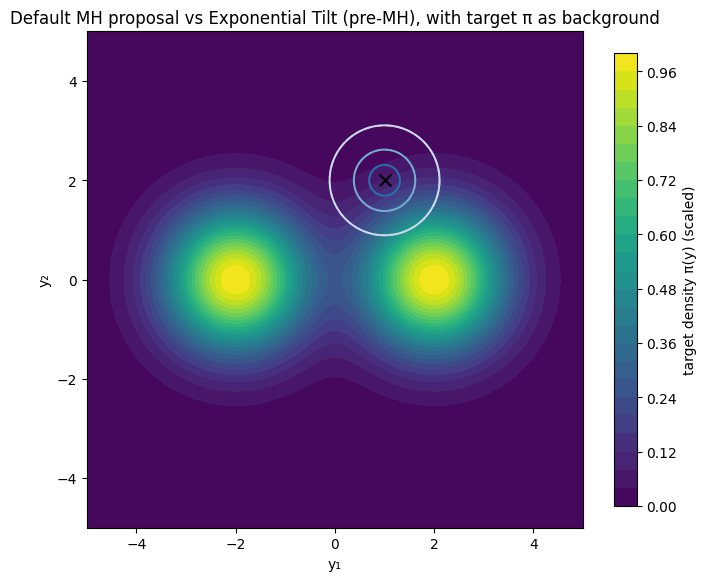

In [129]:
# pip install jax jaxlib matplotlib
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, vmap

# ----------------------------
# Target: 2D Gaussian mixture
# ----------------------------
def logsumexp(a, axis=None):
    m = jnp.max(a, axis=axis, keepdims=True)
    return (m + jnp.log(jnp.sum(jnp.exp(a - m), axis=axis, keepdims=True))).squeeze()

def log_gauss(x, mean, cov_inv, logdet_cov):
    d = x.shape[-1]
    dx = x - mean
    return -0.5 * (jnp.einsum('...i,ij,...j', dx, cov_inv, dx) + logdet_cov + d*jnp.log(2*jnp.pi))

def make_mixture_target(means, covs):
    K, d = means.shape
    cov_invs = jnp.linalg.inv(covs)
    logdets = jnp.log(jnp.linalg.det(covs))
    weights = jnp.ones((K,)) / K

    def logpi(x):
        comps = vmap(lambda m, Ci, ld: log_gauss(x, m, Ci, ld), (0,0,0))(means, cov_invs, logdets)
        logw = jnp.log(weights)
        if comps.ndim > 1:
            logw = logw[:, None]
        return logsumexp(logw + comps, axis=0)
    return logpi

# ----------------------------
# Proposal + accept weight (for psi fit only)
# ----------------------------
def gaussian_propose(key, x, sigma):
    return x + random.normal(key, shape=x.shape) * sigma

def sample_proposals(key, X, sigma, M):
    N, d = X.shape
    keys = random.split(key, N*M)
    Xrep = jnp.repeat(X, repeats=M, axis=0)
    Y = vmap(gaussian_propose, in_axes=(0,0,None))(keys, Xrep, sigma)
    return Y.reshape(N, M, d)

def mh_accept(logpi, x, y):  # symmetric q
    return jnp.minimum(1.0, jnp.exp(logpi(y) - logpi(x)))

# ----------------------------
# RBF RKHS to build psi*
# ----------------------------
def pairwise_sqdist(X, Y):
    diff = X[:, None, :] - Y[None, :, :]
    return jnp.sum(diff * diff, axis=-1)

def median_heuristic_bandwidth(X):
    n = X.shape[0]
    d2 = pairwise_sqdist(X, X)
    mask = jnp.triu(jnp.ones((n, n)), k=1)
    d2_masked = jnp.where(mask > 0, d2, jnp.inf)
    vals = jnp.sort(d2_masked.flatten())
    n_valid = jnp.sum(mask).astype(jnp.int32)
    med_idx = jnp.maximum(0, n_valid // 2 - 1)
    med = vals[med_idx]
    h = jnp.sqrt(0.5 * med + 1e-6)
    return jnp.maximum(h, 1e-3)

def rbf_kernel(X, Y, h):
    return jnp.exp(-pairwise_sqdist(X, Y) / (2.0 * h**2))

def build_kernel_potential(particles, prop_points, alphas, lam=1e-6):
    X = particles                     # (N,2)
    N = X.shape[0]
    M = prop_points.shape[1]
    Y = prop_points.reshape(-1, X.shape[1])   # (N*M,2)
    A = alphas.reshape(-1, 1)                 # (N*M,1)

    U = jnp.concatenate([X, Y], axis=0)       # (D,2)
    h = median_heuristic_bandwidth(U)
    K_UU = rbf_kernel(U, U, h)

    K_UY = rbf_kernel(U, Y, h)                # (D,N*M)
    K_UX = rbf_kernel(U, X, h)                # (D,N)
    K_UX_rep = jnp.repeat(K_UX, repeats=M, axis=1)  # (D,N*M)

    numer = jnp.sum(A.T * (K_UY - K_UX_rep), axis=1)  # (D,)
    b = numer / (N * M)
    D = U.shape[0]
    beta = jnp.linalg.solve(K_UU + lam * jnp.eye(D), b)  # (D,)

    def psi_fn(x):
        x_flat = x.reshape(-1, 2)
        K_xU = rbf_kernel(x_flat, U, h)
        val = K_xU @ beta
        return val.reshape(x.shape[:-1])
    return psi_fn

def build_kernel_potential_raw(particles, prop_points, alphas):
    X = particles                      # (N,d)
    N, d = X.shape
    Y = prop_points.reshape(-1, d)     # (N*M,d)
    A = alphas.reshape(-1, 1)          # (N*M,1)

    U = jnp.concatenate([X, Y], axis=0)
    h = median_heuristic_bandwidth(U)

    def psi_fn(x):
        # x: (..., d)
        x_flat = x.reshape(-1, d)
        K_xY = rbf_kernel(x_flat, Y, h)        # (..., N*M)
        K_xX = rbf_kernel(x_flat, X, h)        # (..., N)
        # broadcast sums
        termY = (K_xY * A.T).sum(axis=-1)      # (...,)
        termX = K_xX.sum(axis=-1)              # (...,)   # if alphas were per-(i,m), for X use sum over i only
        # If you want weights on X matching the number of proposals per i, multiply by M accordingly.
        val = (termY - termX * (A.shape[0] / N)) / (N * (A.shape[0] // N))
        return val.reshape(x.shape[:-1])
    return psi_fn


# ----------------------------
# Visualisation helpers
# ----------------------------
def make_grid(lim=4.5, n=250):
    xs = jnp.linspace(-lim, lim, n)
    ys = jnp.linspace(-lim, lim, n)
    Xg, Yg = jnp.meshgrid(xs, ys, indexing="xy")
    P = jnp.stack([Xg.ravel(), Yg.ravel()], axis=1)  # (n*n, 2)
    return xs, ys, Xg, Yg, P

def log_q_iso(y, x, sigma):  # unnormalised log Gaussian
    d = y - x
    return -0.5 * jnp.sum(d * d, axis=-1) / (sigma**2)

def log_tilted(y, x, sigma, eps, psi, norm_delta=True, eps_floor=1e-8):
    """
    Unnormalised log tilted proposal:
        log q_tilt(y|x) = log q_iso(y|x, sigma) + eps * (Δψ / std(Δψ))
    where Δψ = ψ(y) - ψ(x), and std(Δψ) is computed over all y,x in the current batch.
    """
    delta = psi(y) - psi(x)
    if norm_delta:
        std_delta = jnp.maximum(jnp.std(delta), eps_floor)
        delta_tilde = (delta - delta.mean()) / std_delta
    else:
        delta_tilde = delta
    return log_q_iso(y, x, sigma) + eps * delta_tilde

def eval_on_grid(fun_log, x, P, n):
    L = vmap(lambda yy: fun_log(yy, x))(P)  # (n*n,)
    L = L - jnp.max(L)                      # stabilise so peak = 1 after exp
    Z = jnp.exp(L).reshape(n, n)            # (n, n), aligned with (xs, ys)
    return np.array(Z)

# ----------------------------
# Demo: make psi*, then plot 1 anchor
# ----------------------------
if __name__ == "__main__":
    # Target mixture
    means = jnp.array([[ 2.0, 0.0],
                       [-2.0, 0.0]])
    covs  = jnp.stack([jnp.eye(2), jnp.eye(2)], axis=0)
    logpi = make_mixture_target(means, covs)

    # Settings
    N = 32          # number of particles used to fit psi
    M = 16           # proposals per particle for psi
    sigma = 0.6     # proposal std for MH
    eps = 100.    # tilt strength
    lam = 1e-2      # RKHS ridge
    lim = 5.0       # plot window
    n   = 240       # grid resolution

    # Particles and proposals (only for psi fitting)
    key = random.PRNGKey(0)
    key, kx, ky = random.split(key, 3)
    X = random.normal(kx, (N, 2)) * 10.0            # (N,2)
    Y = sample_proposals(ky, X, sigma, M)          # (N,M,2)
    alphas = vmap(lambda xi, Yi: vmap(lambda y: mh_accept(logpi, xi, y))(Yi))(X, Y)  # (N,M)

    # Build psi*
    psi = build_kernel_potential_raw(X, Y, alphas)

    # Choose ONE anchor x (e.g., the first particle)
    # x_anchor = X[0]
    x_anchor = jnp.array([1., 2.0])  # alternatively, centre at origin
    # Grid
    xs, ys, Xg, Yg, P = make_grid(lim=lim, n=n)

    # Background: target density contourf
    logp_grid = logpi(P).reshape(n, n)
    p_grid = np.exp(np.array(logp_grid))
    # normalise only for nicer colour scaling (optional)
    p_grid = p_grid / (p_grid.max() + 1e-12)

    # Default MH proposal (dashed contours), centred at x_anchor
    Z_base = eval_on_grid(lambda y, x: log_q_iso(y, x, sigma), x_anchor, P, n)

    # Exponentially tilted proposal (solid contours), same centre
    Z_tilt = eval_on_grid(lambda y, x: log_tilted(y, x, sigma, eps, psi), x_anchor, P, n)

    # ---------------- Plot ----------------
    fig, ax = plt.subplots(figsize=(7, 6))

    # 1) target as contourf
    cf = ax.contourf(xs, ys, p_grid, levels=30, alpha=1.)
    cbar = fig.colorbar(cf, ax=ax, shrink=0.85, label="target density π(y) (scaled)")

    # 2) default MH proposal (dashed)
    cs_base = ax.contour(xs, ys, jnp.exp(Z_base), levels=2, linestyles="dashed", linewidths=1.2, alpha=0.9, cmap='Reds')
    cs_base.collections[0].set_label("Base q(y|x)")

    # 3) tilted proposal (solid)
    cs_tilt = ax.contour(xs, ys, jnp.exp(Z_tilt), levels=2, linewidths=1.4, cmap='Blues')
    cs_tilt.collections[0].set_label("Tilted q̃ε(y|x) (unnormalised)")

    # 4) mark the anchor
    ax.scatter([float(x_anchor[0])], [float(x_anchor[1])], s=70, marker="x", color="k", label="anchor x")

    ax.set_title("Default MH proposal vs Exponential Tilt (pre-MH), with target π as background")
    ax.set_xlabel("y₁"); ax.set_ylabel("y₂")
    # ax.legend(loc="upper right")
    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()
    plt.show()


In [105]:
psi(P)  # example usage

Array([-0.22928253, -0.22927305, -0.22926196, ..., -0.18485206,
       -0.18461984, -0.184387  ], dtype=float32)

In [128]:
Z_tilt

array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       ...,
       [1.4305139e-27, 2.8661031e-27, 5.7144918e-27, ..., 4.1572839e-15,
        2.6307323e-15, 1.6566334e-15],
       [1.0167921e-27, 2.0371996e-27, 4.0618078e-27, ..., 2.9549473e-15,
        1.8699002e-15, 1.1775196e-15],
       [7.1921702e-28, 1.4409858e-27, 2.8730653e-27, ..., 2.0901504e-15,
        1.3226487e-15, 8.3290269e-16]], dtype=float32)

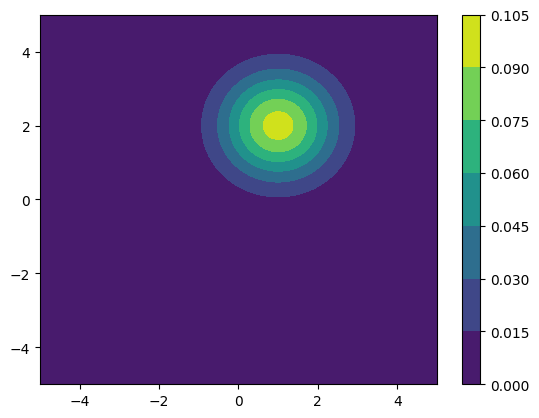

In [109]:
deltas = psi(P) - psi(x_anchor)
deltas  = deltas / (jnp.std(deltas) + 1e-8)
plt.contourf(xs, ys, jnp.exp(log_gauss(P, x_anchor, jnp.eye(2), 1)).reshape(n, n))
plt.colorbar()

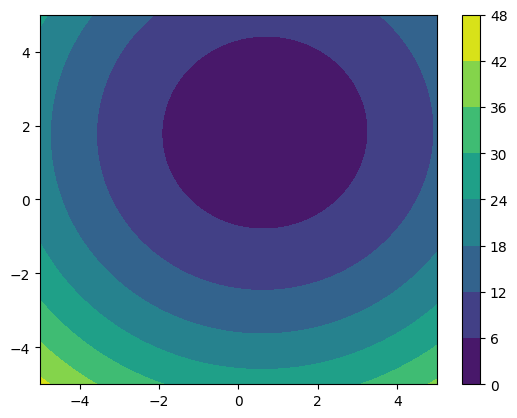

In [119]:
deltas = psi(P) - psi(x_anchor)
deltas  = (deltas - jnp.mean(deltas)) / (jnp.std(deltas) + 1e-8)
plt.contourf(xs, ys, (1 * deltas - log_gauss(P, x_anchor, jnp.eye(2), 1)).reshape(n, n))
plt.colorbar()

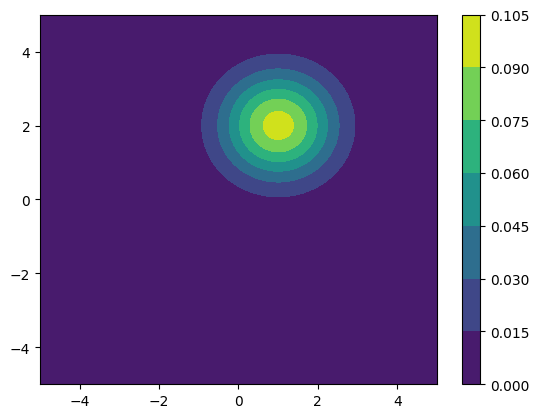

In [113]:
deltas = psi(P) - psi(x_anchor)
deltas  = (deltas - jnp.mean(deltas)) / (jnp.std(deltas) + 1e-8)
plt.contourf(xs, ys, (jnp.exp(0.01 * deltas) * jnp.exp(log_gauss(P, x_anchor, jnp.eye(2), 1)) ).reshape(n, n))
plt.colorbar()

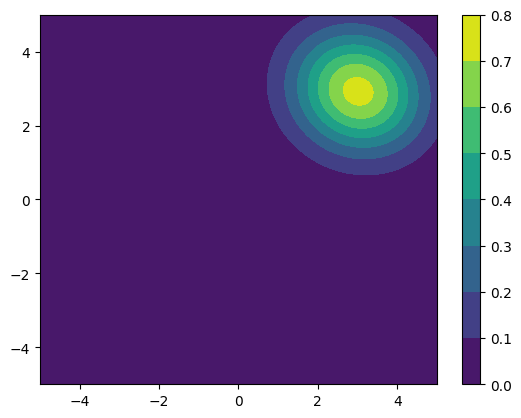

In [107]:
plt.contourf(xs, ys, (jnp.exp(400. * (psi(P) - psi(x_anchor))) * jnp.exp(log_gauss(P, x_anchor, jnp.eye(2), 1)) ).reshape(n, n))
plt.colorbar()

In [31]:
Z_base = eval_on_grid(lambda y, x: log_q_iso(y, x, sigma), x_anchor, P, n)
# Z_tilt = eval_on_grid(lambda y, x: log_tilted(y, x, sigma, eps, psi), x_anchor, P, n)
Z_base

array([[4.7250818e-34, 8.9324218e-34, 1.6804224e-33, ..., 1.4332942e-27,
        8.5578726e-28, 5.0848210e-28],
       [8.4281907e-34, 1.5932878e-33, 2.9973916e-33, ..., 2.5565857e-27,
        1.5264672e-27, 9.0698618e-28],
       [1.4960476e-33, 2.8281685e-33, 5.3205255e-33, ..., 4.5380722e-27,
        2.7095793e-27, 1.6099476e-27],
       ...,
       [1.4960476e-33, 2.8281685e-33, 5.3205255e-33, ..., 4.5380722e-27,
        2.7095793e-27, 1.6099476e-27],
       [8.4281907e-34, 1.5932999e-33, 2.9973916e-33, ..., 2.5565953e-27,
        1.5264848e-27, 9.0698965e-28],
       [4.7250818e-34, 8.9324218e-34, 1.6804224e-33, ..., 1.4332942e-27,
        8.5578726e-28, 5.0848210e-28]], dtype=float32)

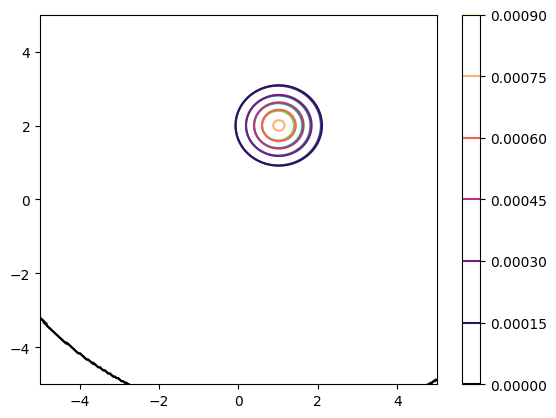

In [54]:


plt.contour(xs, ys, Z_base, levels=5)
plt.contour(xs, ys, Z_tilt / Z_tilt.sum(), levels=5, cmap='magma')
plt.colorbar()

In [56]:
Z_tilt

array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       ...,
       [1.3416000e-27, 2.6872628e-27, 5.3566082e-27, ..., 5.4554817e-15,
        3.4615431e-15, 2.1857012e-15],
       [9.5512952e-28, 1.9131514e-27, 3.8135323e-27, ..., 3.8819829e-15,
        2.4631466e-15, 1.5552897e-15],
       [6.7669682e-28, 1.3554377e-27, 2.7018278e-27, ..., 2.7489605e-15,
        1.7442222e-15, 1.1013436e-15]], dtype=float32)

In [55]:
Z_base

array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       ...,
       [1.4305139e-27, 2.8661031e-27, 5.7144918e-27, ..., 4.1572839e-15,
        2.6307323e-15, 1.6566334e-15],
       [1.0167921e-27, 2.0371996e-27, 4.0618078e-27, ..., 2.9549473e-15,
        1.8699002e-15, 1.1775196e-15],
       [7.1921702e-28, 1.4409858e-27, 2.8730653e-27, ..., 2.0901504e-15,
        1.3226487e-15, 8.3290269e-16]], dtype=float32)

In [33]:
Z_tilt = eval_on_grid(lambda y, x: log_tilted(y, x, sigma, eps, psi), x_anchor, P, n)
Z_tilt

array([[4.7173378e-34, 8.9177823e-34, 1.6776683e-33, ..., 1.4313273e-27,
        8.5461283e-28, 5.0778429e-28],
       [8.4144411e-34, 1.5906887e-33, 2.9925019e-33, ..., 2.5530869e-27,
        1.5243782e-27, 9.0574502e-28],
       [1.4936184e-33, 2.8235764e-33, 5.3118863e-33, ..., 4.5318788e-27,
        2.7058815e-27, 1.6077504e-27],
       ...,
       [1.4938349e-33, 2.8239856e-33, 5.3126970e-33, ..., 4.5313950e-27,
        2.7055924e-27, 1.6075787e-27],
       [8.4156616e-34, 1.5909434e-33, 2.9929585e-33, ..., 2.5528240e-27,
        1.5242329e-27, 9.0565170e-28],
       [4.7180578e-34, 8.9191433e-34, 1.6779243e-33, ..., 1.4311743e-27,
        8.5452154e-28, 5.0773007e-28]], dtype=float32)

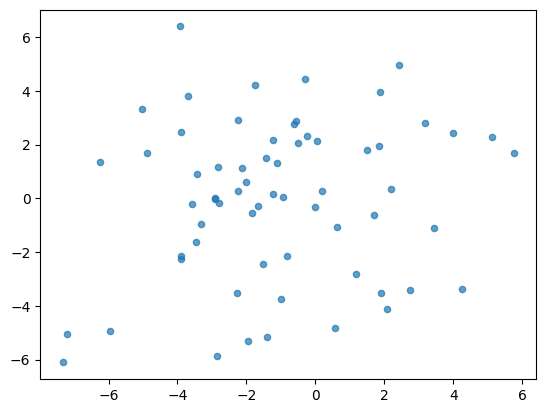

In [23]:
plt.scatter(X.T[0], X.T[1], s=20, alpha=0.7)